## Importando as bibliotecas

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats as st

## Extraindo as informações dos arquivos

In [33]:
df_hypothesis = pd.read_csv('data/hypotheses_us.csv', delimiter=';')
df_orders = pd.read_csv('data/orders_us.csv',
                       parse_dates=['date'])
df_visits = pd.read_csv('data/visits_us.csv',
                        parse_dates=['date'])

In [34]:
# Ordena e exibe a informações iniciais
dfs = {
    'hypothesis':df_hypothesis,
    'orders':df_orders,
    'visits':df_visits
    }

for name, df in dfs.items():
    print(f'-------{name.upper()}-------')
    print(df.info())
    print()
    display(df.head())
    print(f"Linhas duplicadas: {df.duplicated().sum()}")
    print()

-------HYPOTHESIS-------
<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Hypothesis  9 non-null      str  
 1   Reach       9 non-null      int64
 2   Impact      9 non-null      int64
 3   Confidence  9 non-null      int64
 4   Effort      9 non-null      int64
dtypes: int64(4), str(1)
memory usage: 492.0 bytes
None



,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1


Linhas duplicadas: 0

-------ORDERS-------
<class 'pandas.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1197 non-null   int64         
 1   visitorId      1197 non-null   int64         
 2   date           1197 non-null   datetime64[us]
 3   revenue        1197 non-null   float64       
 4   group          1197 non-null   str           
dtypes: datetime64[us](1), float64(1), int64(2), str(1)
memory usage: 46.9 KB
None



,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B


Linhas duplicadas: 0

-------VISITS-------
<class 'pandas.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    62 non-null     datetime64[us]
 1   group   62 non-null     str           
 2   visits  62 non-null     int64         
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 1.6 KB
None



,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


Linhas duplicadas: 0



In [35]:
df_hypothesis.columns = [column.lower() for column in df_hypothesis.columns] # Fortamando o nomes das colunas de df_hypothesis

In [ ]:
group_check = df_orders.groupby('visitorId')['group'].nunique().reset_index()
duplicate_visitors = group_check[group_check['group'] > 1]['visitorId']
print(f"clientes presentes em mais de um grupo: {len(duplicate_visitors)}")
df_orders = df_orders[np.logical_not(df_orders['visitorId'].isin(duplicate_visitors))]

clientes presentes em mais de um grupo: 58


For realizada uma checagem nos grupos, afim de verificar se algum cliente esteve presente em ambos os grupos, o que poderia distorcer o estudo.\
Foi detectado 58 clientes, eles seram removidos afim de termos métricas mais precisas.

# Priorizando Hipóteses

In [37]:
df_hypothesis['ice'] = ((df_hypothesis['impact'] * df_hypothesis['confidence']) / df_hypothesis['effort']).round(2) # Calcula o ICE
df_hypothesis['rice'] = ((df_hypothesis['reach'] * df_hypothesis['impact'] * df_hypothesis['confidence']) / df_hypothesis['effort']).round(2) # Calcula o RICE

display(df_hypothesis[['hypothesis', 'ice']].sort_values(by='ice', ascending=False)) # Exibe o ranking da melhor hipótese baseada no ICE
display(df_hypothesis[['hypothesis', 'rice']].sort_values(by='rice', ascending=False)) # Exibe o ranking da melhor hipótese baseada no RICE

,hypothesis,ice
8,Launch a promotion that gives users discounts ...,16.20
0,Add two new channels for attracting traffic. T...,13.33
7,Add a subscription form to all the main pages....,11.20
6,Show banners with current offers and sales on ...,8.00
2,Add product recommendation blocks to the store...,7.00
1,Launch your own delivery service. This will sh...,2.00
5,Add a customer review page. This will increase...,1.33
3,Change the category structure. This will incre...,1.12
4,Change the background color on the main page. ...,1.00


,hypothesis,rice
7,Add a subscription form to all the main pages....,112.0
2,Add product recommendation blocks to the store...,56.0
0,Add two new channels for attracting traffic. T...,40.0
6,Show banners with current offers and sales on ...,40.0
8,Launch a promotion that gives users discounts ...,16.2
3,Change the category structure. This will incre...,9.0
1,Launch your own delivery service. This will sh...,4.0
5,Add a customer review page. This will increase...,4.0
4,Change the background color on the main page. ...,3.0


### Observações

As tabelas mostram que as mesmas 5 hipóteses dominam em cada métrica calculada.\

A comparação dos rankings de ICE e RICE mostra que a **hipótese 7** (Add a subscription form to all...), que estava em 3º lugar no ICE, passa para **1.º lugar** no RICE graças ao parâmetro de **Alcance (Reach)**, que possui 10 pontos. Em contrapartida, a **hipótese 8** (Launch a promotion that gives...) cai para o último lugar do top 5, pois possui um alcance muito baixo (1 ponto), o que reduz significativamente a sua pontuação no cálculo do RICE.

A diferença entre os rankings é justificada pelo **parametro do alcance** que é incluido no calculo do **RICE**, o qual não esta presente no **ICE**.\
Por isso, hipóteses com grande público-alvo (hipótese 7) sobem no ranking, enquanto hipóteses direcionadas a poucas pessoas (Hipótese 8) perdem posições no RICE.

# Análise de teste A/B

In [38]:
datesGroups = df_orders[['date','group']].drop_duplicates() # Separa a data únicas de cada grupo

#================================================
# Obtem a receita de cada grupo separado por data
#================================================
ordersAggregated = datesGroups.apply(
    lambda x: df_orders[
        np.logical_and(
            df_orders['date'] <= x['date'], df_orders['group'] == x['group']
            )
        ].agg(
                {
                    'date':'max',
                    'group':'max',
                    'transactionId': pd.Series.nunique,
                    'visitorId':pd.Series.nunique,
                    'revenue':'sum'
                }
            ), axis=1
            ).sort_values(by=['date','group'])

#=====================================================================
# Obtem a quantidade de cada visitante de cada grupo separado por data
#=====================================================================
visitorsAggregated = datesGroups.apply(
    lambda x: df_visits[
        np.logical_and(
            df_visits['date'] <= x['date'], df_visits['group'] == x['group']
            )
        ].agg(
                {
                    'date':'max',
                    'group':'max',
                    'visits':'sum'
                }
            ), axis=1
            ).sort_values(by=['date','group'])

#==============================================
# Une ambos os dataframes e renomeia as colunas
#==============================================
cumulativeData = ordersAggregated.merge(visitorsAggregated, left_on=['date', 'group'], right_on=['date', 'group'])
cumulativeData.columns = [
    'date',
    'group',
    'orders',
    'buyers',
    'revenue',
    'visitors']

In [39]:
print(f'-----RECEITA POR GRUPO-----\n{ordersAggregated.head()}',
      f'\n\n-----VISITAS POR GRUPO-----\n{visitorsAggregated.head()}'
      f'\n\n-----DADOS AGRUPADOS-----\n{cumulativeData.head()}')

-----RECEITA POR GRUPO-----
          date group  transactionId  visitorId  revenue
55  2019-08-01     A             23         19   2266.6
66  2019-08-01     B             17         17    967.2
175 2019-08-02     A             42         36   3734.9
173 2019-08-02     B             40         39   3535.3
291 2019-08-03     A             66         60   5550.1 

-----VISITAS POR GRUPO-----
          date group  visits
55  2019-08-01     A     719
66  2019-08-01     B     713
175 2019-08-02     A    1338
173 2019-08-02     B    1294
291 2019-08-03     A    1845

-----DADOS AGRUPADOS-----
        date group  orders  buyers  revenue  visitors
0 2019-08-01     A      23      19   2266.6       719
1 2019-08-01     B      17      17    967.2       713
2 2019-08-02     A      42      36   3734.9      1338
3 2019-08-02     B      40      39   3535.3      1294
4 2019-08-03     A      66      60   5550.1      1845


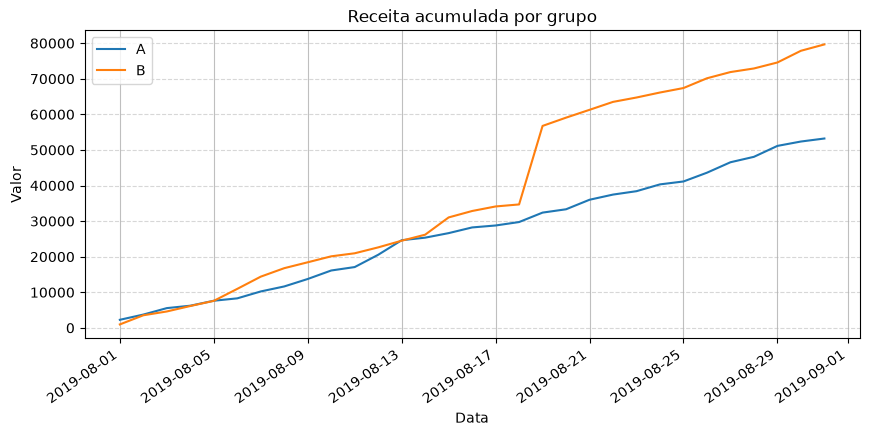

In [40]:
# Cria o dataframe com a receita separada por grupo
cumulativeDataA = cumulativeData[cumulativeData['group']=='A'][['date', 'revenue','orders']]
cumulativeDataB = cumulativeData[cumulativeData['group']=='B'][['date', 'revenue','orders']]

# Exibe os dataframes criados em formato de linha
plt.figure(figsize=(10,4))
plt.plot(cumulativeDataA['date'],cumulativeDataA['revenue'],label='A')
plt.plot(cumulativeDataB['date'],cumulativeDataB['revenue'],label='B')
plt.grid(axis='y', linestyle='--' ,alpha=0.5)
plt.grid(axis='x', alpha=0.8)
plt.xticks(rotation=35, ha='right')
plt.title('Receita acumulada por grupo')
plt.ylabel('Valor')
plt.xlabel('Data')
plt.legend()
plt.show()

O gráfico de receita acumulada mostra que apenas nos primeiros dias os grupos se mantiveram juntos, mas a partir de 05 de agosto o grupo B monstrou dominio sobre o A. Porém ainda não podemos ter certeza que o grupo B foi melhor.\
O crescimento vertical do grupo B na segunda metade de agosto, indica que houve comprar atípicas e muito caras ocorreram naquele perido.

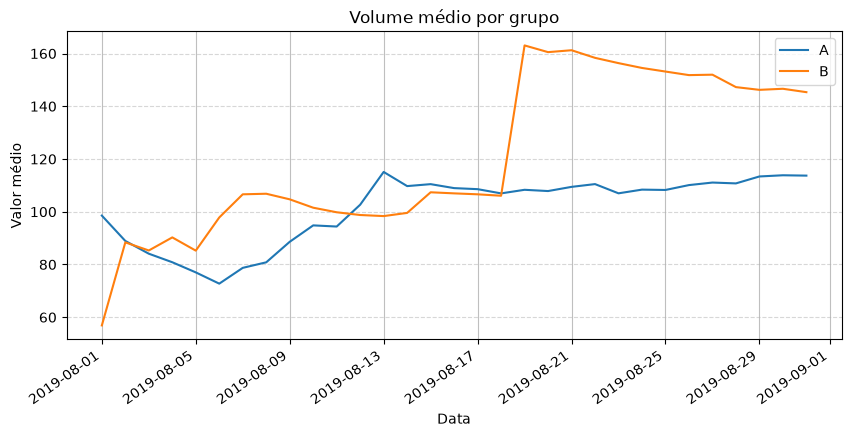

In [41]:
# Exibe, em formato de linha, um gráfico com o volume médio por grupo
plt.figure(figsize=(10,4))
plt.plot(cumulativeDataA['date'],cumulativeDataA['revenue']/cumulativeDataA['orders'],label='A')
plt.plot(cumulativeDataB['date'],cumulativeDataB['revenue']/cumulativeDataB['orders'],label='B')
plt.grid(axis='y', linestyle='--' ,alpha=0.5)
plt.grid(axis='x', alpha=0.8)
plt.xticks(rotation=35, ha='right')
plt.title('Volume médio por grupo')
plt.ylabel('Valor médio')
plt.xlabel('Data')
plt.legend()
plt.show()

O gráfico de ticket médio apresenta muita oscilação até o mesmo periodo visto anteriormente, onde tivemos um outlier no grupo B.\
Entre a oscilação, o grupo B mostra forte dominio, e só é ultrapassado pelo grupo A no dia 12 de agosto onde se mantém o dia 18, onde foi justamente o pico do mesmo grupo ~118$ por compra.\

No final do grafíco, ambos os grupos seguem em formato de funil, com o grupo B declinando suavemente, e o grupo A aumentando na mesma proporção.\
Isso levanta uma questão, e se o grupo B, não tivesse esse outlier? o grupo A teria um dominio maior?

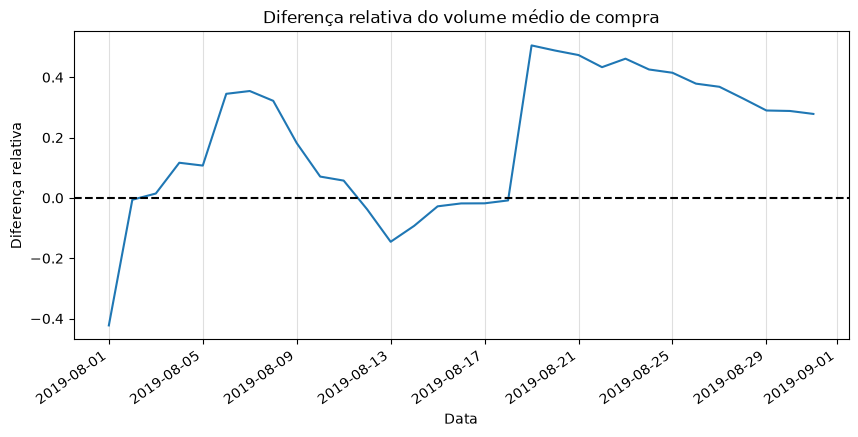

In [42]:
# Junta ambos os dataframes criados e usados anteriormente para a obtenção de métricas
mergedCumulativeRevenue = cumulativeDataA.merge(cumulativeDataB, left_on='date', right_on='date', how='left', suffixes=['A','B'])

# Exibe a diferença relativa entre os grupos
# Acima de 0 representa domínio do grupo B
# Abaixo de 0 representa domínio do grupo A
plt.figure(figsize=(10,4))
plt.plot(mergedCumulativeRevenue['date'],
         (mergedCumulativeRevenue['revenueB']/mergedCumulativeRevenue['ordersB'])
         /
         (mergedCumulativeRevenue['revenueA']/mergedCumulativeRevenue['ordersA']) -1)
plt.xticks(rotation=35, ha='right')
plt.title('Diferença relativa do volume médio de compra')
plt.ylabel('Diferença relativa')
plt.xlabel('Data')
plt.axhline(y=0, color='black', linestyle='--')
plt.grid(axis='x', alpha=0.4)
plt.show()

O gráfico da diferença relativa mostra que o grupo B dominou na maior parte do tempo em relação ao grupo A.\
O outlier detectado distorçe a visualização, que facilmente mostraria o grupo B abaixo de 0. Vale a pena estudar esse caso como um teste de hipótese.

# --- GERAR 2 TABELAS SEM O OUTLIER DO B ---

# --- REVISAR ---

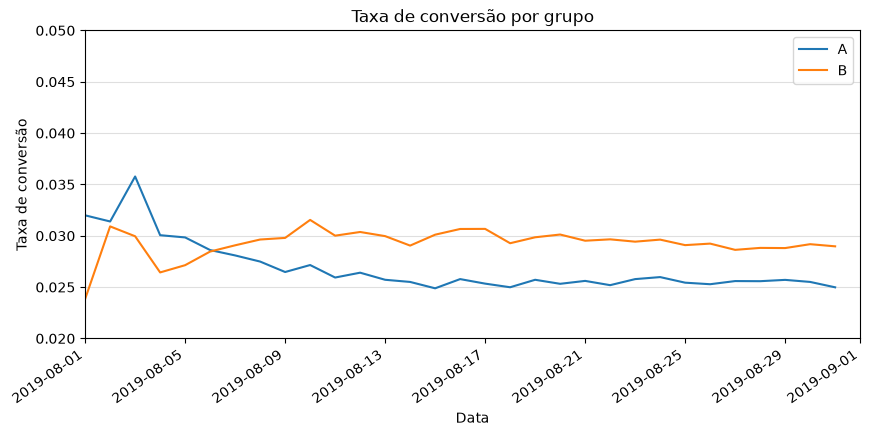

In [43]:
# Calcula a taxa de conversão geral
cumulativeData['conversion'] = cumulativeData['orders']/cumulativeData['visitors']

# Separa por grupo
cumulativeDataA = cumulativeData[cumulativeData['group']=='A']
cumulativeDataB = cumulativeData[cumulativeData['group']=='B']

# Exibe, em gráfico de linha, a difença da conversão entre os grupos
plt.figure(figsize=(10,4))
plt.plot(cumulativeDataA['date'],cumulativeDataA['conversion'],label='A')
plt.plot(cumulativeDataB['date'],cumulativeDataB['conversion'],label='B')
plt.xticks(rotation=35, ha='right')
plt.title('Taxa de conversão por grupo')
plt.ylabel('Taxa de conversão')
plt.xlabel('Data')
plt.grid(axis='y', alpha=0.4)
plt.legend()
plt.axis([pd.to_datetime('2019-08-01'), pd.to_datetime('2019-09-01'), 0.02, 0.05])
plt.show()

O grupo A foi predominante nos primeiras dias, antes do grupo B elevar voltar ao dominio já conhecido.\
O grupo B possui uma leve curva no periodo da anomalia detectada.\
Ambos seguiram estabilizados pela maior parte do tempo.

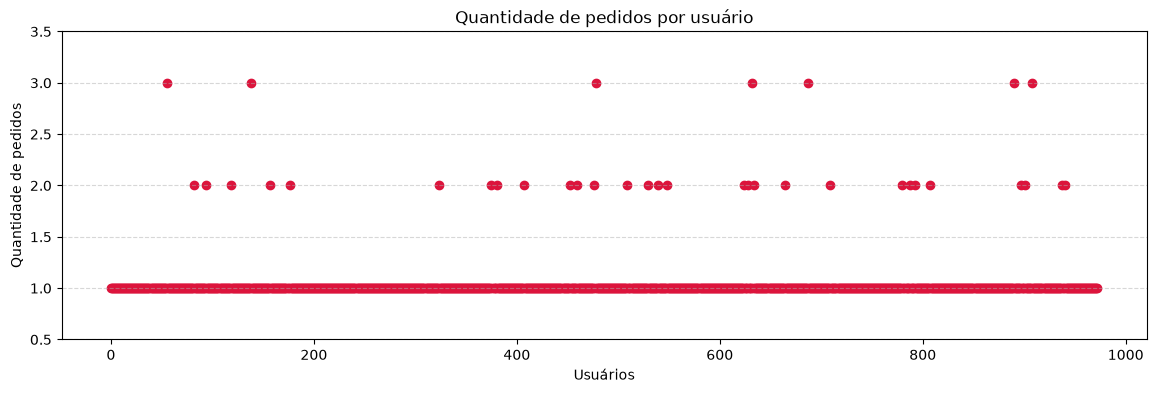

In [44]:
# Agrupa por a contagem de pedidos por usuário
orders_by_user = df_orders.groupby('visitorId', as_index=False).agg({'transactionId': pd.Series.nunique})
orders_by_user.columns = ['userId', 'orders']
x_values_orders = pd.Series(range(0, len(orders_by_user)))

# Exibe, em gráfico de dispersão, a quantidade de pedidos por usuário
plt.figure(figsize=(14,4))
plt.scatter(x_values_orders,orders_by_user['orders'],
            color='crimson')
plt.grid(axis='y', alpha=0.5, linestyle='--')
plt.title('Quantidade de pedidos por usuário')
plt.ylabel('Quantidade de pedidos')
plt.xlabel('Usuários')
plt.ylim(0.5, 3.5)
plt.show()

O gráfico nos diz que a maior parte dos clientes realizaram apenas 1 pedido, e um apenas um grupo de pessoas fizeram de 2 a 3 pedidos.\
Para esse critério, não temos outliers relevantes para calcular as diferenças.

In [45]:
# Calcula os percentis da quantidade de pedidos
print(f"Os respectivos percentis 95 e 99 são: {np.percentile(orders_by_user['orders'],[95, 99])}")

Os respectivos percentis 95 e 99 são: [1. 2.]


Os percentis nos confirmam que menos de 95% dos usuários fizeram 1 pedido e 99% deles fizeram 2 ou menos.\
Não temos critérios relevantes para a difinição de um limiar.

# --- FAZER + 1 GRAFICO SEM O OUTLIER ---

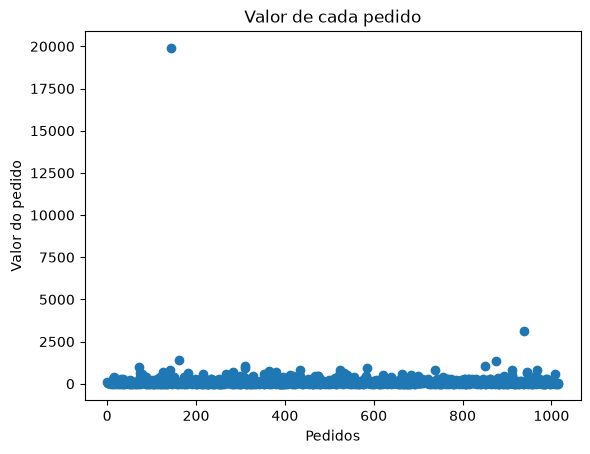

In [46]:
# Agrupa o valor de cada pedido
price_by_order = df_orders.groupby('transactionId', as_index=False).agg({'revenue':'sum'})
price_by_order.columns = ['order', 'revenue']
x_values_price = pd.Series(range(0, len(price_by_order)))

# Exibe, em gráfico de dispersão, o valor de cada pedido
plt.scatter(x_values_price, price_by_order['revenue'])
plt.title('Valor de cada pedido')
plt.ylabel('Valor do pedido')
plt.xlabel('Pedidos')
plt.show()

A dispersão do gráfico confirma que há um outlier totalmente fora do comum, um pedido de quase $20mil, enquanto a grande maior parte se mantem abaixo dos $2500

In [47]:
# Calcula os percentis do valor dos pedidos
print(f"Os respectivos percentis 95 e 99 são: {np.percentile(price_by_order['revenue'],[95, 99])}")

Os respectivos percentis 95 e 99 são: [414.275 830.3  ]


Os percentis mostram que menos de 1% dos clientes fizeram pedidos acima de $900, o que foge totalmente do outlier visto anteriormente.\
Também é afirmado que menos de 5% da clientela fizeram pedidos acima de $430, assim, iremos considerar uma anomalia qualquer valor acima desse.

In [48]:
# Agrupa a quantidade de pedidos, desta vez, separado por grupo
orders_by_user_A = df_orders[df_orders['group'] == 'A'].groupby(
    'visitorId', as_index=False).agg({'transactionId': pd.Series.nunique})

orders_by_user_B = df_orders[df_orders['group'] == 'B'].groupby(
    'visitorId', as_index=False).agg({'transactionId': pd.Series.nunique})

# Renomeia as colunas
orders_by_user_A.columns = ['userId', 'qty_orders']
orders_by_user_B.columns = ['userId', 'qty_orders']

In [49]:
# Cria uma amostra de pedidos para cada grupo, preenchendo com 0 os visitantes que não realizaram pedidos
sampleA = pd.concat(
    [orders_by_user_A['qty_orders'],
     pd.Series(0,
               index=np.arange(
                   df_visits[df_visits['group']=='A']['visits'].sum() - len(orders_by_user_A)
                   ), name='qty_orders')],
                   axis=0) 

sampleB = pd.concat(
    [orders_by_user_B['qty_orders'],
     pd.Series(0,
               index=np.arange(
                   df_visits[df_visits['group']=='B']['visits'].sum() - len(orders_by_user_B)
                   ), name='qty_orders')],
                   axis=0)

# Calculo de significância estatística para dados **brutos**

In [50]:
# Calcula e exibe a significância estatística da conversão e a diferença relativa entre os grupos
print(f"A significância estatística da conversão é de {'{0:.5f}'.format(st.mannwhitneyu(sampleA,sampleB)[1])}")
print(f"A diferença relativa da conversão é de {'{0:.3f}'.format(sampleB.mean()/sampleA.mean() - 1)}")
print()
# Calcula e exibe a significância estatística do volume médio do pedido e a diferença relativa entre os grupos
print(f"A significância estatística do volume médio do pedido é de {'{0:.3f}'.format(st.mannwhitneyu(
    df_orders[df_orders['group'] == 'A']['revenue'],
    df_orders[df_orders['group'] == 'B']['revenue']
    )[1])}")
print(f"A diferença relativa do volume médio é de {'{0:.3f}'.format(
    df_orders[df_orders['group'] == 'B']['revenue'].mean() / df_orders[df_orders['group'] == 'A']['revenue'].mean() - 1)}")

A significância estatística da conversão é de 0.01102
A diferença relativa da conversão é de 0.160

A significância estatística do volume médio do pedido é de 0.862
A diferença relativa do volume médio é de 0.278


# --- REVISAR ---

## Observações dos dados brutos

### Conversão
- Possui um valor-p baixo, o que implica que taxas de conversão dos grupos **possuem diferenças estatísticas significativas**
- O ganho do grupo B, em relação ao grupo A é de 13,8%

### Volume médio
- Possui um valor-p muito alto, indicando que **não há diferenças estatisticas** entre o volume médio dos grupos
- A difença relativa entre eles é de 27,8%

# Calculo de significância estatística para dados **Filtrados**

In [51]:
# Filtra usuários com mais de 4 pedidos ou com pedidos acima de 430
users_with_many_orders = pd.concat([
    orders_by_user_A[orders_by_user_A['qty_orders'] >= 4]['userId'],
    orders_by_user_B[orders_by_user_B['qty_orders'] >= 4]['userId']])

users_with_expensive_orders = df_orders[df_orders['revenue'] > 430]['visitorId']
abnormal_users = pd.concat([users_with_many_orders, users_with_expensive_orders], axis=0).drop_duplicates().sort_values()
print(f'Usuários com pedidos anormais: {abnormal_users.shape[0]}')

Usuários com pedidos anormais: 49


In [52]:
# Cria uma amostra de pedidos para cada grupo, preenchendo com 0 os visitantes que não realizaram pedidos, filtrando os usuários anormais
sampleAFiltered = pd.concat([
    orders_by_user_A[
        np.logical_not(
            orders_by_user_A['userId'].isin(abnormal_users))]['qty_orders'],
            pd.Series(0, index=np.arange(
                df_visits[df_visits['group'] == 'A']['visits'].sum() -
                len(orders_by_user_A['qty_orders'] 
            )), name='orders'
        )],axis=0)

sampleBFiltered = pd.concat([
    orders_by_user_B[
        np.logical_not(
            orders_by_user_B['userId'].isin(abnormal_users))]['qty_orders'],
            pd.Series(0, index=np.arange(
                df_visits[df_visits['group'] == 'B']['visits'].sum() -
                len(orders_by_user_B['qty_orders'] 
            )), name='orders'
        )],axis=0)

In [53]:
# Calcula e exibe a significância estatística da conversão e a diferença relativa entre os grupos
print(f"A significância estatística da conversão é de {'{0:.3f}'.format(st.mannwhitneyu(sampleAFiltered, sampleBFiltered)[1])}")
print(f"A diferença relativa da conversão é de {'{0:.3f}'.format(sampleBFiltered.mean()/sampleAFiltered.mean() - 1)}")
print()
# Calcula e exibe a significância estatística do volume médio do pedido e a diferença relativa entre os grupos
print(f"A significância estatística do volume médio do pedido é de {'{0:.3f}'.format(st.mannwhitneyu(
    df_orders[np.logical_and(
        df_orders['group'] == 'A',
        np.logical_not(
            df_orders['visitorId'].isin(abnormal_users)))]['revenue'],
    df_orders[np.logical_and(
        df_orders['group'] == 'B',
        np.logical_not(
            df_orders['visitorId'].isin(abnormal_users)))]['revenue']
        )[1])}")
print(f"A diferença relativa do volume médio é de {'{0:.3f}'.format(
    df_orders[np.logical_and(
        df_orders['group'] == 'B',
        np.logical_not(
            df_orders['visitorId'].isin(abnormal_users)))]['revenue'].mean()
    /
    df_orders[np.logical_and(
        df_orders['group'] == 'A',
        np.logical_not(
            df_orders['visitorId'].isin(abnormal_users)))]['revenue'].mean() -1
        )}")

A significância estatística da conversão é de 0.014
A diferença relativa da conversão é de 0.160

A significância estatística do volume médio do pedido é de 0.856
A diferença relativa do volume médio é de -0.035


## Observações dos dados filtrados

### Conversão
- Possui um valor-p baixo, o que implica que taxas de conversão dos dados filtrados dos grupos **possuem diferenças estatísticas significativas**
- O ganho do grupo B, em relação ao grupo A é de 14,7%

### Volume médio
- Novamente o valor-p é muito alto, indicando que **não há diferenças estatisticas** entre o volume médio dos grupos
- A difença relativa entre eles é de -2,4%

# Conclusão final

Durante todo o estudo do caso, o grupo B apresentou forte dominío sobre o grupo A, porém a anomalia de uma compra de ~20mil causava um ruido nos valores.\
Com isso, foi realizado um teste estatístico para obter a prova real do caso, e da mesma forma, o grupo B apresentou forte poder de conversão, independente do outlier detectado.\
Foram realizado testes com os dados brutos e com os dados filtrados, e em ambos o grupo B apresentava um ganho da conversão acima de 13%.\
Concluimos que o teste foi um sucesso e pode ser encerrado com a permanência das alterações do grupo B mantidas.